Input: 
1. data: pd.DataFrame, with PV generation data and weather data, no normalized data

Output: 
1. The WIS graph
2. The table of 19 confidence intervals results, which consists of sharpness, calibration, interval score, and WIS.


This file splits the households into 2 groups, group 1 with 10 households as training data and group 2 with 11 households as testing.

1. Create 
2. Run capacity estimation with group 1 and group 2, obtain the error factor
3. Train point regressor with group 1.
4. Make point predictions with group 2
5. Construct the prediction interval for group 2 
6. Evaluate the intervals

In [1]:
import sys
import os

# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [2]:
# Imports
import timeit
from modules.preprocessing import data_preprocessor
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from mapie.regression import MapieQuantileRegressor
from crepes.extras import margin, DifficultyEstimator, MondrianCategorizer
from crepes import WrapRegressor
import scienceplots
from modules.capacity_estimation_aus import (
    capacity_estimation_base_load,
    sensitivity_analysis_irradiance_threshold,
)

from modules.utils import (
    get_values,
    calc_penalty,
    calculate_coverage,
    calculate_mean_size,
    calculate_median_size,
    calc_multi_level,
    calc_multi_level_WIS,
    calc_multi_level_cqr,
    calc_multi_level_cqr_WIS,
    calc_size_stratified_coverage,
    plot_actual_vs_predicted,
    calc_percentage_error,
    calc_mean_percentage_error,
    calc_error_factor,
    calc_r2_score,
    read_column_list_from_config,
    split_households,
    preprocess_two_groups,
    cp_data_preparation,
    cqr_multi_level_eval,
    adaptive_mondrian_bins
)
from modules.capacity_estimation_aus import capacity_estimation_error_factor

In [3]:
plt.style.use(["science"])
# constants
general_seed = 42
n_splits = 10
list_of_features = ["ghi_norm", "total_net_norm", "air_temp_norm",
                    "azimuth_norm"]
# Create non-overlapping bin sequence
# list_of_bins = list(range(2, 10)) + list(range(10, 50, 2)) + \
#     list(range(50, 101, 5))
list_of_bins = [2, 3, 4, 5, 6, 7, 8, 9,
                10, 15, 20, 30,  50,  70, 90, 100]

In [4]:
all_metrics_test = np.zeros((n_splits, len(list_of_bins)))
all_metrics_cal = np.zeros((n_splits, len(list_of_bins)))

In [5]:
# Read data
fname = "../data/ausgrid/ausgrid_merged_unprocessed.csv"
df = pd.read_csv(fname)
df = df[(df['datetime'] >= '2012-07-01')
        & (df['datetime'] <= '2013-07-01')]
# reset the index
df = df.reset_index(drop=True)

In [6]:
for split in range(n_splits):
    # Set a different seed for each split
    seed = split + 1  # using split+1 to avoid seed=0
    np.random.seed(seed)
    print(f"Split {split + 1} of {n_splits}")
    time_columns = read_column_list_from_config("../config/time_columns.txt")
    weather_columns = read_column_list_from_config(
        "../config/weather_columns_preprocess.txt"
    )
    feature_columns = read_column_list_from_config(
        "../config/feature_columns_preprocess.txt"
    )
    # Split the households into 2 groups
    n_1, n_2 = 39, 38
    df_1, df_2 = split_households(
        df,
        n_1=n_1,
        n_2=n_2,
        seed=seed,
        date_columns=time_columns,
        weather_columns=weather_columns,
    )
    preprocessor_1 = data_preprocessor(df_1)
    preprocessor_2 = data_preprocessor(df_2)
    # Preprocess the data
    preprocessed_data_part1, preprocessed_data_part2 = preprocess_two_groups(
        preprocessor_1=preprocessor_1,
        preprocessor_2=preprocessor_2,
        feature_columns=feature_columns,
    )
    # prepare data for CP
    X_prop_train, y_prop_train, X_cal, y_cal, X_test, y_test, len_test = (
        cp_data_preparation(
            df_1=preprocessed_data_part1,
            df_2=preprocessed_data_part2,
            list_of_features=list_of_features,
        )
    )

    lgb = WrapRegressor(
        LGBMRegressor(
            n_jobs=-1, n_estimators=100, random_state=seed, verbose=-1
        )
    )
    lgb.fit(X_prop_train, y_prop_train)
    # run the 8 prob methods
    for i, no_bins in enumerate(list_of_bins):
        learner_prop = lgb.learner
        learner = WrapRegressor(learner_prop)
        mc = MondrianCategorizer()
        mc.fit(X=X_cal, f=get_values, no_bins=no_bins)
        learner.calibrate(
            X_cal,
            y_cal,
            cps=True,
            mc=mc,
            seed=seed,
        )
        wis_test = calc_multi_level_WIS(learner, X_test, y_test)
        wis_cal = calc_multi_level_WIS(learner, X_cal, y_cal)
        all_metrics_test[split, i] = wis_test
        all_metrics_cal[split, i] = wis_cal

Split 1 of 10


/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/crepes/base.py:2404: UserWarning: the no. of calibration examples is too small for some lower percentile in the following bins:0 1 2 3 4 5 6 7 8 9 ...; the corresponding values are set to y_min

Split 2 of 10


/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/crepes/base.py:2404: UserWarning: the no. of calibration examples is too small for some lower percentile in the following bins:0 1 2 3 4 5 6 7 8 9 ...; the corresponding values are set to y_min

Split 3 of 10


...

/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/crepes/base.py:2404: UserWarning: the no. of calibration examples is too small for some lower percentile in the following bins:7; the corresponding values are set to y_min
  warnings.warn("the 

Split 9 of 10


/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/crepes/base.py:2404: UserWarning: the no. of calibration examples is too small for some lower percentile in the following bins:0 1 2 3 4 5 6 7 8 9 ...; the corresponding values are set to y_min

Split 10 of 10


/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/crepes/base.py:2404: UserWarning: the no. of calibration examples is too small for some lower percentile in the following bins:19; the corresponding values are set to y_min
  warnings.warn("the

In [7]:
# save all_metrics_test to a numpy file
np.save(
    f"../data/results/all_metrics_cal_ausgrid_seed{general_seed}_1year_wis_bins_cps.npy",
    all_metrics_cal
)
np.save(
    f"../data/results/all_metrics_test_ausgrid_seed{general_seed}_1year_wis_bins_cps.npy",
    all_metrics_test
)

In [8]:
# give me the statistics of all metrics for each method, organized by the order of prob_methods
all_metrics_test = np.load(
    f"../data/results/all_metrics_test_ausgrid_seed{general_seed}_1year_wis_bins_cps.npy"
)
all_metrics_cal = np.load(
    f"../data/results/all_metrics_cal_ausgrid_seed{general_seed}_1year_wis_bins_cps.npy"
)
# plot the wis against the number of bins

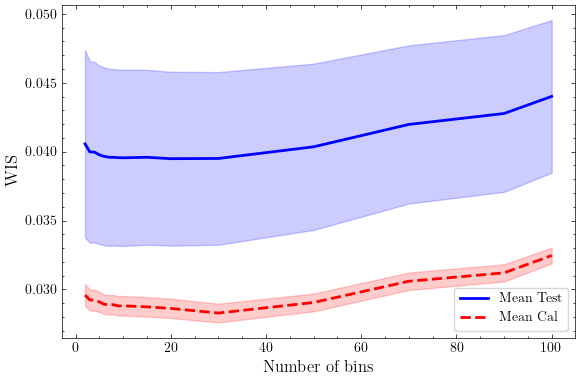

Mean Test WIS range: 0.0395 to 0.0440
Mean Cal WIS range: 0.0283 to 0.0325


In [18]:
# Calculate mean and standard error across splits
mean_test = np.mean(all_metrics_test, axis=0)
mean_cal = np.mean(all_metrics_cal, axis=0)

# Calculate standard error of the mean (SEM) for confidence intervals
sem_test = np.std(all_metrics_test, axis=0) / np.sqrt(n_splits)
sem_cal = np.std(all_metrics_cal, axis=0) / np.sqrt(n_splits)

# Sort by number of bins to prevent the line from going backwards
sorted_indices = sorted(range(len(list_of_bins)),
                        key=lambda i: list_of_bins[i])
bins_sorted = [list_of_bins[i] for i in sorted_indices]
mean_test_sorted = mean_test[sorted_indices]
mean_cal_sorted = mean_cal[sorted_indices]
sem_test_sorted = sem_test[sorted_indices]
sem_cal_sorted = sem_cal[sorted_indices]

# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))

# Plot mean lines with shaded confidence intervals
ax.plot(bins_sorted, mean_test_sorted, color='Blue', linewidth=2,
        label='Mean Test', markersize=4)
ax.fill_between(bins_sorted, mean_test_sorted - 1.96*sem_test_sorted,
                mean_test_sorted + 1.96*sem_test_sorted,
                color='Blue', alpha=0.2)

ax.plot(bins_sorted, mean_cal_sorted, color='Red', linewidth=2,
        label='Mean Cal', linestyle='--', markersize=4)
ax.fill_between(bins_sorted, mean_cal_sorted - 1.96*sem_cal_sorted,
                mean_cal_sorted + 1.96*sem_cal_sorted,
                color='Red', alpha=0.2)

# Formatting
ax.set_xlabel('Number of bins', fontsize=12)
ax.set_ylabel('WIS', fontsize=12, rotation=90)
ax.legend(loc='best', fontsize=10, frameon=True)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"../figs/WIS_vs_no_bins_cps_mond_ausgrid.pdf", format="pdf")
plt.show()


print(
    f"Mean Test WIS range: {mean_test_sorted.min():.4f} to {mean_test_sorted.max():.4f}")
print(
    f"Mean Cal WIS range: {mean_cal_sorted.min():.4f} to {mean_cal_sorted.max():.4f}")

In [11]:
# Check the bin sequence to make sure it's strictly increasing
print(f"Number of bins: {len(list_of_bins)}")
print(f"First 10 bins: {list_of_bins[:10]}")
print(f"Last 10 bins: {list_of_bins[-10:]}")
print(
    f"Is strictly increasing: {all(list_of_bins[i] < list_of_bins[i+1] for i in range(len(list_of_bins)-1))}")
print(f"Bins with step 1 (2-9): {list(range(2, 10))}")
print(f"Bins with step 2 (10-18): {list(range(10, 20, 2))}")
print(f"Bins with step 5 (20-45): {list(range(20, 50, 5))}")
print(f"Bins with step 10 (50-100): {list(range(50, 101, 10))}")

Number of bins: 16
First 10 bins: [2, 3, 4, 5, 6, 7, 8, 9, 10, 15]
Last 10 bins: [8, 9, 10, 15, 20, 30, 50, 70, 90, 100]
Is strictly increasing: True
Bins with step 1 (2-9): [2, 3, 4, 5, 6, 7, 8, 9]
Bins with step 2 (10-18): [10, 12, 14, 16, 18]
Bins with step 5 (20-45): [20, 25, 30, 35, 40, 45]
Bins with step 10 (50-100): [50, 60, 70, 80, 90, 100]
